In [1]:
import pandas as pd
import numpy as np

In [2]:

df = pd.read_csv("synthetic_customer_churn.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [4]:
df['PaymentMethod'].unique()

array(['Bank transfer', 'Mailed check', 'Electronic check', 'Credit card'],
      dtype=object)

In [5]:
df.drop(columns=['CustomerID'], inplace=True)

In [6]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Churn'].value_counts()
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       29348
                Yes      25567
One year        No       21030
                Yes       4231
Two year        No       16478
                Yes       3346
Name: count, dtype: int64

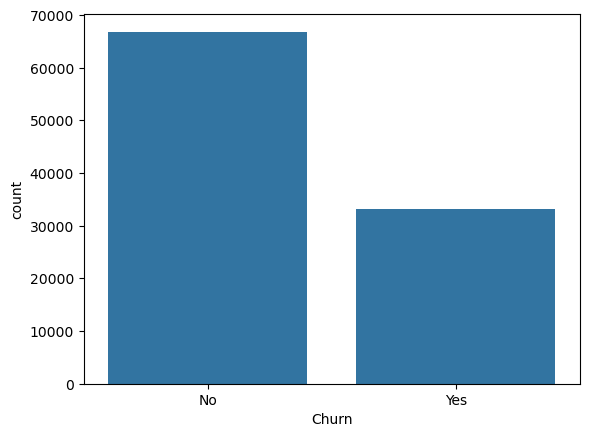

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

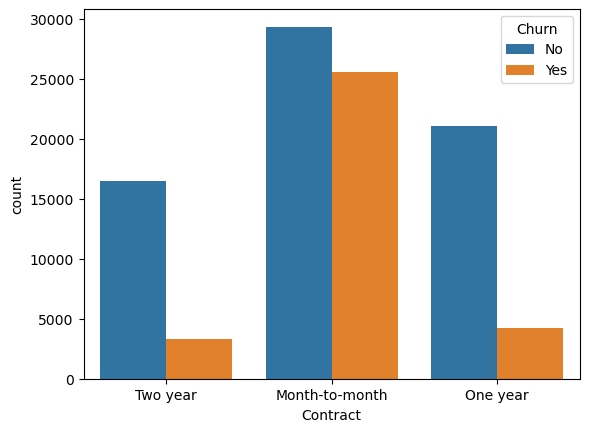

In [10]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

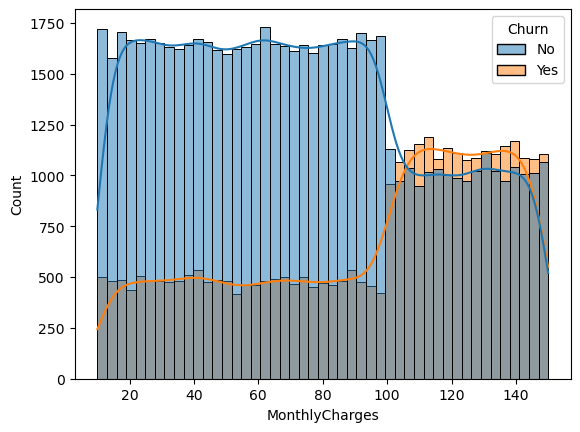

In [11]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.show()

In [12]:
# Making x and y Category

x = df.drop(columns = ["Churn"], axis = 1)
y = df["Churn"]

In [13]:
x

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges
0,56,Female,68,147.58,Two year,Bank transfer,10052.03
1,69,Male,32,22.54,Month-to-month,Mailed check,686.78
2,46,Female,10,52.47,One year,Electronic check,537.88
3,32,Male,22,109.67,Month-to-month,Mailed check,2390.04
4,60,Female,54,130.98,Month-to-month,Credit card,7081.28
...,...,...,...,...,...,...,...
99995,31,Male,49,26.07,Month-to-month,Electronic check,1220.50
99996,64,Female,44,123.22,Month-to-month,Mailed check,5384.38
99997,48,Other,32,75.37,Month-to-month,Credit card,2372.33
99998,42,Female,60,114.00,Month-to-month,Mailed check,6826.55


In [14]:
y

0         No
1         No
2         No
3        Yes
4         No
        ... 
99995     No
99996     No
99997    Yes
99998     No
99999     No
Name: Churn, Length: 100000, dtype: object

In [15]:
df.isnull().sum()

Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [16]:
df

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,46,Female,10,52.47,One year,Electronic check,537.88,No
3,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No
...,...,...,...,...,...,...,...,...
99995,31,Male,49,26.07,Month-to-month,Electronic check,1220.50,No
99996,64,Female,44,123.22,Month-to-month,Mailed check,5384.38,No
99997,48,Other,32,75.37,Month-to-month,Credit card,2372.33,Yes
99998,42,Female,60,114.00,Month-to-month,Mailed check,6826.55,No


In [17]:
# using labelEncoder()
# Label Encoder (from scikit-learn) is used to convert categorical text data into numbers.
    
from sklearn.preprocessing import LabelEncoder, StandardScaler

encoder = LabelEncoder()
y_int = encoder.fit_transform(y)


In [18]:
x = pd.get_dummies(x, drop_first=True)   #our dataset has columns like:

# Gender (Male, Female)
# Contract (One year, Two year)

#  Models cannot understand text
#  So we convert them into numbers

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y_int,
                                                    test_size=0.20, 
                                                    random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [21]:
# Creating Model using LogisticRegression

from sklearn.linear_model import LogisticRegression

#  We use Logistic Regression because our target (Churn) is Yes/No, and it predicts probability of a class.

model = LogisticRegression(max_iter=1000)   # max_iter=1000 → it can try up to 1000 times to find the best solution  
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
# Seeing which Columns is more useful for findind churn

importance = pd.Series(model.coef_[0],index=x.columns)
importance.sort_values(ascending=False).head(10)

MonthlyCharges                    0.506897
TotalCharges                      0.278394
Gender_Male                       0.022198
PaymentMethod_Mailed check        0.019718
Gender_Other                      0.012650
PaymentMethod_Electronic check    0.003504
PaymentMethod_Credit card         0.001974
Age                              -0.003207
Contract_Two year                -0.656964
Contract_One year                -0.716741
dtype: float64

In [23]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 1, ..., 0, 1, 0])

In [24]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.72375


In [25]:
# Creating Model using DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

# Create model
model = DecisionTreeClassifier()

# Train
model.fit(x_train, y_train)



DecisionTreeClassifier()

In [26]:
# Predict
y_pred = model.predict(x_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [27]:
# Accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.6804


In [28]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
model.fit(x_train, y_train)



RandomForestClassifier(random_state=42)

In [29]:
# Predict
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 1, 1])

In [30]:
# Accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.73155


In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[11269  2025]
 [ 3344  3362]]


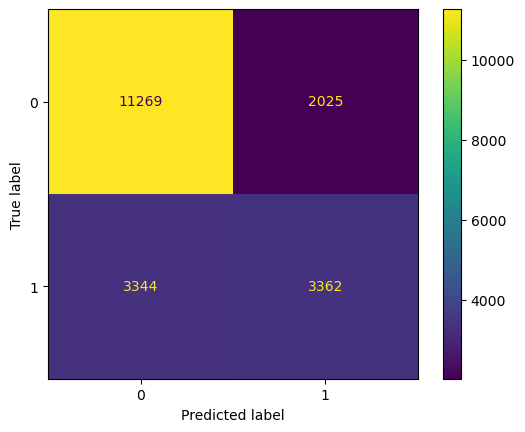

In [32]:

ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)